In [ ]:
# Run once
!pip install torch torchvision torchaudio


import os, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print("Torch:", torch.__version__, "Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))


Torch: 2.8.0+cu126 Device: cuda


In [ ]:
import torch
print("Torch:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Torch: 2.8.0+cu126
Device: cuda


In [ ]:
!pip install numpy pandas matplotlib scikit-learn einops


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive


 20JE0283_Chanchal_Rawate_lab_7.docx
 20JE0283.gdoc
'20JE0283_LAB-5 (PERT).docx'
'20JE0283_Lab Experiment 5 - Implementation of Program Evaluation and Review Technique (PERT).gdoc'
'20JE0283- Lab Experiment 5 - Implementation of Program Evaluation and Review Technique (PERT).gdoc'
'4.5 SQL Scripts for Lecture.rar'
'Admission_form (1).jpg'
 Admission_form.jpg
'Application for Employment_Internship (1).gdoc'
'Application for Employment_Internship (1).pdf'
'ayushi mam_resume_.pdf .gdoc'
'ayushi mam_resume_.pdf .pdf'
 bonafide_certificate_20je0283.pdf
 Chanchal_Rawate_lab_7.docx
'Chanchal_Rawate_Resume (2).pdf'
 Chanchal_Rawate_Resume.pdf
 chanchu.jpg
'Class materials.zip'
'Class notes.gdoc'
 Classroom
'Colab Notebooks'
'Copy of Lab Experiment 4 -  Implementation of Critical Path Method (CPM).gdoc'
'Cyberlabs_Proposal_Chanchal Rawate.pdf'
 equinoctial_to_cartesian.cpp
'EXPERIMENT _ 9 (2).pdf'
'Group- 13_Software_engineering project.gdoc'
 IMG_20220921_202636.jpg
'Infosys Certificates'
'LAB

In [ ]:
!ls /content/drive/MyDrive/TEC_Project


tecdata.xlsx


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/TEC_Project/tecdata.xlsx"  # 👈 inside quotes!
data = pd.read_excel(path)

print("✅ Data loaded successfully!")
print(data.head())
print("\nColumns:", data.columns)


✅ Data loaded successfully!
        DATE  DOY  HOD       DNS       DNC       HRS       HRC        f107  \
0 2012-01-01    1    0  0.017213  0.999852  0.000000  1.000000  129.600000   
1 2012-01-01    1    1  0.017213  0.999852  0.258819  0.965926  129.647917   
2 2012-01-01    1    2  0.017213  0.999852  0.500000  0.866025  129.694090   
3 2012-01-01    1    3  0.017213  0.999852  0.707107  0.707107  129.738535   
4 2012-01-01    1    4  0.017213  0.999852  0.866025  0.500000  129.781267   

         ap  f0F2(t-23)  f0F2  hmF2(t-23)   hmF2  TEC(t-23)   TEC  
0  6.000000        3.85   NaN       329.6    NaN       9.96  7.86  
1  5.333333        3.85   NaN       348.7    NaN       9.60  7.80  
2  4.666667        3.85  3.45       367.6  304.9       8.87  7.40  
3  4.000000        4.60   NaN       247.9    NaN       8.46  6.82  
4  3.666667        2.80  3.55       251.8  285.1       7.68  6.46  

Columns: Index(['DATE', 'DOY', 'HOD', 'DNS', 'DNC', 'HRS', 'HRC', 'f107', 'ap',
       'f0F2(t

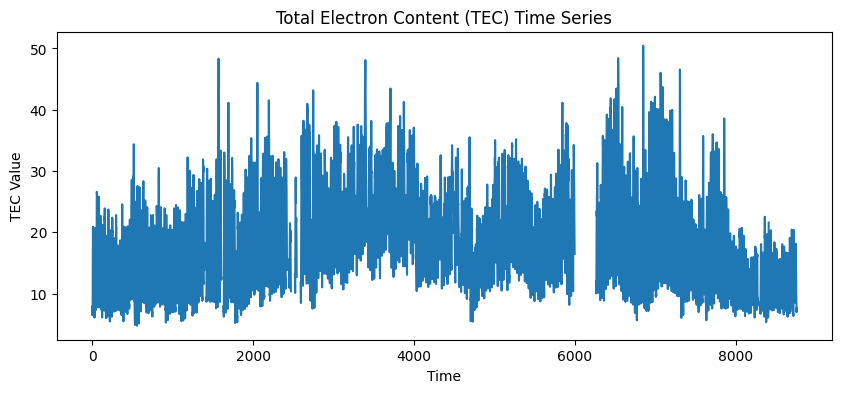

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(data.iloc[:, -1])  # plots the last column (likely TEC)
plt.title("Total Electron Content (TEC) Time Series")
plt.xlabel("Time")
plt.ylabel("TEC Value")
plt.show()


In [ ]:
features = ['DNS', 'DNC', 'HRS', 'HRC', 'f107', 'ap',
             'f0F2(t-23)', 'f0F2', 'hmF2(t-23)', 'hmF2', 'TEC(t-23)']

target = ['TEC']


In [ ]:
X = data[features].values
y = data[target].values


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

data = data.fillna(method='ffill').fillna(method='bfill')


/tmp/ipython-input-3292455182.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


In [ ]:
train_size = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]


In [ ]:
seq_len = 48
label_len = 24
pred_len = 12


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# Create custom Dataset class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len, label_len, pred_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len
        self.label_len = label_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len

    def __getitem__(self, idx):
        s_begin = idx
        s_end = s_begin + self.seq_len
        r_begin = s_end - self.label_len
        r_end = r_begin + self.label_len + self.pred_len

        seq_x = torch.tensor(self.X[s_begin:s_end], dtype=torch.float32)
        seq_y = torch.tensor(self.y[r_begin:r_end], dtype=torch.float32)
        return seq_x, seq_y

# Create dataset loaders
train_data = TimeSeriesDataset(X_train, y_train, seq_len, label_len, pred_len)
test_data  = TimeSeriesDataset(X_test, y_test, seq_len, label_len, pred_len)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("Sequence datasets ready!")
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Sequence datasets ready!
Train samples: 6948
Test samples: 1692


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from math import sqrt

# ----- Informer Components -----
class AttentionLayer(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.query = nn.Linear(d_model, d_model)
        self.key   = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.scale = sqrt(d_model)
        self.softmax = nn.Softmax(dim=-1)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        Q, K, V = self.query(x), self.key(x), self.value(x)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        weights = self.softmax(scores)
        output = torch.matmul(weights, V)
        return self.out(output)

class InformerBlock(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.attn = AttentionLayer(d_model)
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + attn_out)
        ff_out = F.relu(self.fc1(x))
        ff_out = self.fc2(ff_out)
        return self.norm2(x + ff_out)

class InformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, hidden_dim=128, output_dim=1, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([InformerBlock(d_model, hidden_dim) for _ in range(num_layers)])
        self.output = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)
        return self.output(x[:, -1, :])  # last time step output


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]
model = InformerModel(input_dim=input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for seq_x, seq_y in train_loader:
        seq_x, seq_y = seq_x.to(device), seq_y.to(device)
        optimizer.zero_grad()
        output = model(seq_x)
        loss = criterion(output, seq_y[:, -1, :])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.6f}")


Epoch [1/10] Loss: nan
Epoch [2/10] Loss: nan
Epoch [3/10] Loss: nan
Epoch [4/10] Loss: nan
Epoch [5/10] Loss: nan
Epoch [6/10] Loss: nan
Epoch [7/10] Loss: nan
Epoch [8/10] Loss: nan
Epoch [9/10] Loss: nan
Epoch [10/10] Loss: nan


In [ ]:
mzprint("NaN count before cleaning:", data.isna().sum())


NaN count before cleaning: DATE          0
DOY           0
HOD           0
DNS           0
DNC           0
HRS           0
HRC           0
f107          0
ap            0
f0F2(t-23)    0
f0F2          0
hmF2(t-23)    0
hmF2          0
TEC(t-23)     0
TEC           0
dtype: int64


In [ ]:
data = data.fillna(method='ffill').fillna(method='bfill')
data = data.replace([np.inf, -np.inf], np.nan).dropna()


/tmp/ipython-input-437519805.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['DNS', 'DNC', 'HRS', 'HRC', 'f107', 'ap',
             'f0F2(t-23)', 'f0F2', 'hmF2(t-23)', 'hmF2', 'TEC(t-23)']
target = ['TEC']

X = data[features].values
y = data[target].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


In [ ]:
print(np.isnan(X_scaled).any(), np.isnan(y_scaled).any())


False False


In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


tensor(nan, device='cuda:0')

In [ ]:
from tqdm import tqdm


In [ ]:
from tqdm import tqdm  # ✅ import tqdm for progress bar

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, leave=False)

    for seq_x, seq_y in loop:
        seq_x, seq_y = seq_x.to(device), seq_y.to(device)

        optimizer.zero_grad()
        output = model(seq_x)

        # Make sure target has same shape as output
        target_seq = seq_y[:, -1, :output.shape[-1]]

        loss = criterion(output, target_seq)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Avg Loss: {avg_loss:.6f}")


✅ Epoch [1/10] Avg Loss: nan


✅ Epoch [2/10] Avg Loss: nan


✅ Epoch [3/10] Avg Loss: nan


✅ Epoch [4/10] Avg Loss: nan


✅ Epoch [5/10] Avg Loss: nan


✅ Epoch [6/10] Avg Loss: nan


✅ Epoch [7/10] Avg Loss: nan


✅ Epoch [8/10] Avg Loss: nan


✅ Epoch [9/10] Avg Loss: nan


✅ Epoch [10/10] Avg Loss: nan


In [ ]:
print("NaNs in X_scaled:", np.isnan(X_scaled).sum())
print("NaNs in y_scaled:", np.isnan(y_scaled).sum())
print("Infs in X_scaled:", np.isinf(X_scaled).sum())
print("Infs in y_scaled:", np.isinf(y_scaled).sum())

print("X range:", X_scaled.min(), X_scaled.max())
print("y range:", y_scaled.min(), y_scaled.max())


NaNs in X_scaled: 0
NaNs in y_scaled: 0
Infs in X_scaled: 0
Infs in y_scaled: 0
X range: -3.0100291421713044 15.495410538892079
y range: -1.6515899782230763 3.938393920270149


In [ ]:
# Clip outliers beyond 3 standard deviations
for col in features:
    mean = data[col].mean()
    std = data[col].std()
    data[col] = np.clip(data[col], mean - 3*std, mean + 3*std)


In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(data[features].values)
y_scaled = scaler_y.fit_transform(data[target].values)


In [ ]:
# Rebuild model fresh
model = InformerModel(input_dim=X_scaled.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.MSELoss()


In [ ]:
print("Mean of X_scaled:", np.mean(X_scaled))
print("Std of X_scaled:", np.std(X_scaled))
print("Min/Max:", np.min(X_scaled), np.max(X_scaled))


Mean of X_scaled: -2.123664465534546e-17
Std of X_scaled: 1.0
Min/Max: -3.002474406593756 4.08890707957563


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, eps=1e-8)


In [ ]:
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)


InformerModel(
  (input_proj): Linear(in_features=11, out_features=64, bias=True)
  (layers): ModuleList(
    (0-1): 2 x InformerBlock(
      (attn): AttentionLayer(
        (query): Linear(in_features=64, out_features=64, bias=True)
        (key): Linear(in_features=64, out_features=64, bias=True)
        (value): Linear(in_features=64, out_features=64, bias=True)
        (softmax): Softmax(dim=-1)
        (out): Linear(in_features=64, out_features=64, bias=True)
      )
      (fc1): Linear(in_features=64, out_features=128, bias=True)
      (fc2): Linear(in_features=128, out_features=64, bias=True)
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (output): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

# Apply the initialization
model.apply(init_weights)
print("✅ Xavier initialization applied successfully!")


✅ Xavier initialization applied successfully!


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, eps=1e-8)


In [ ]:
import numpy as np
import torch

# Check inputs to model
for seq_x, seq_y in train_loader:
    print("Input stats before model:")
    print(f"Min: {seq_x.min().item():.4f}, Max: {seq_x.max().item():.4f}, Mean: {seq_x.mean().item():.4f}, Std: {seq_x.std().item():.4f}")
    break  # just show one batch


Input stats before model:
Min: nan, Max: nan, Mean: nan, Std: nan


In [ ]:
import pandas as pd
import numpy as np

# ✅ Replace this path with your actual file path in Google Drive
file_path = "/content/drive/MyDrive/TEC_Project/tecdata.xlsx"

# Load dataset
df = pd.read_excel(file_path)

# Clean it
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print("✅ Cleaned data shape:", df.shape)
print("Any NaNs left?", df.isna().sum().sum())
print("Columns:", df.columns.tolist()[:10], "...")


✅ Cleaned data shape: (6003, 15)
Any NaNs left? 0
Columns: ['DATE', 'DOY', 'HOD', 'DNS', 'DNC', 'HRS', 'HRC', 'f107', 'ap', 'f0F2(t-23)'] ...


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define which columns to use
feature_cols = [
    'DOY', 'HOD', 'DNS', 'DNC', 'HRS', 'HRC',
    'f107', 'ap', 'f0F2(t-23)', 'f0F2', 'hmF2(t-23)',
    'hmF2', 'TEC(t-23)'
]
target_col = ['TEC']

# Make sure all exist
for col in feature_cols + target_col:
    if col not in df.columns:
        print(f"⚠️ Missing column: {col}")

# Drop any missing rows again (safety)
df = df.dropna(subset=feature_cols + target_col)

# Apply scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df[feature_cols])
y = scaler_y.fit_transform(df[target_col])

print("✅ Normalized successfully!")
print(f"X stats → Min: {X.min():.3f}, Max: {X.max():.3f}, Mean: {X.mean():.3f}, Std: {X.std():.3f}")
print(f"y stats → Min: {y.min():.3f}, Max: {y.max():.3f}, Mean: {y.mean():.3f}, Std: {y.std():.3f}")


✅ Normalized successfully!
X stats → Min: -3.097, Max: 10.429, Mean: -0.000, Std: 1.000
y stats → Min: -1.514, Max: 3.989, Mean: 0.000, Std: 1.000


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Convert arrays to tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Sequence length: use last 24 hours to predict next TEC value
seq_len = 24

X_seq = []
y_seq = []

for i in range(len(X_tensor) - seq_len):
    X_seq.append(X_tensor[i:i+seq_len])
    y_seq.append(y_tensor[i+seq_len])  # predict next value

X_seq = torch.stack(X_seq)
y_seq = torch.stack(y_seq)

# Split into train/test (80/20)
split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# Dataloaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

print("✅ DataLoader ready!")
print("Training batches:", len(train_loader))
print("Input sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)


✅ DataLoader ready!
Training batches: 150
Input sequence shape: torch.Size([5979, 24, 13])
Target shape: torch.Size([5979, 1])


In [ ]:
import torch.nn as nn
import torch

# ------------------------------
# Informer building blocks
# ------------------------------
class AttentionLayer(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.softmax = nn.Softmax(dim=-1)
        self.out = nn.Linear(d_model, d_model)
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

    def forward(self, x):
        B, L, D = x.shape
        q = self.query(x).view(B, L, self.num_heads, self.d_k)
        k = self.key(x).view(B, L, self.num_heads, self.d_k)
        v = self.value(x).view(B, L, self.num_heads, self.d_k)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn_weights = self.softmax(attn_scores)
        attn_out = torch.matmul(attn_weights, v)

        out = attn_out.view(B, L, D)
        return self.out(out)


class InformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        self.attn = AttentionLayer(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout(self.attn(x))
        x = self.norm1(x)
        x = x + self.dropout(self.ff(x))
        x = self.norm2(x)
        return x


class InformerModel(nn.Module):
    def __init__(self, input_dim, d_model=32, num_heads=2, num_layers=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.layers = nn.ModuleList([
            InformerBlock(d_model, num_heads, dropout) for _ in range(num_layers)
        ])
        self.output = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        for layer in self.layers:
            x = layer(x)
        return self.output(x[:, -1, :])


In [ ]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = InformerModel(input_dim=X.shape[1], d_model=32, num_heads=2, num_layers=1, dropout=0.2).to(device)
model.apply(init_weights)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-8)

print("✅ Model ready on", device)


✅ Model ready on cuda


In [ ]:
from tqdm import tqdm

num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    loop = tqdm(train_loader, leave=False)

    for seq_x, seq_y in loop:
        seq_x, seq_y = seq_x.to(device), seq_y.to(device)
        optimizer.zero_grad()
        output = model(seq_x)

        if torch.isnan(output).any() or torch.isinf(output).any():
            continue

        loss = criterion(output, seq_y)
        if torch.isnan(loss) or torch.isinf(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / max(1, len(train_loader))
    train_losses.append(avg_loss)
    print(f"✅ Epoch [{epoch+1}/{num_epochs}] Avg Loss: {avg_loss:.6f}")


✅ Epoch [1/20] Avg Loss: 1.238642


✅ Epoch [2/20] Avg Loss: 0.397481


✅ Epoch [3/20] Avg Loss: 0.292062


✅ Epoch [4/20] Avg Loss: 0.249298


✅ Epoch [5/20] Avg Loss: 0.221871


...

✅ Epoch [16/20] Avg Loss: 0.137620


✅ Epoch [17/20] Avg Loss: 0.135071


✅ Epoch [18/20] Avg Loss: 0.133591


✅ Epoch [19/20] Avg Loss: 0.135306


✅ Epoch [20/20] Avg Loss: 0.129448


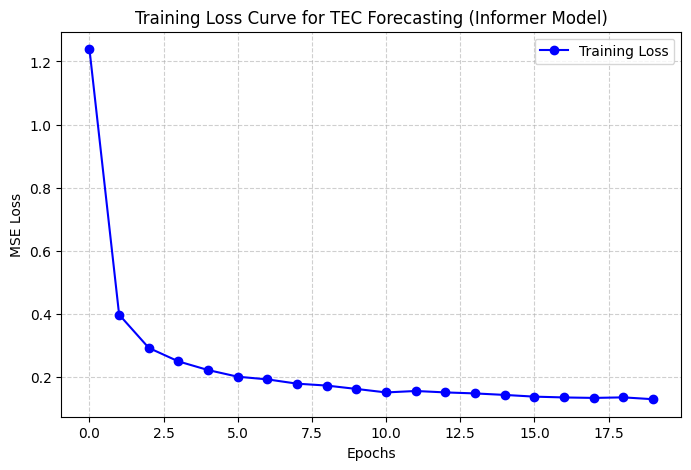

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o', label='Training Loss', color='blue')
plt.title("Training Loss Curve for TEC Forecasting (Informer Model)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


📊 Model Evaluation Metrics:
   → Mean Absolute Error (MAE): 2.8708
   → Root Mean Square Error (RMSE): 3.8958


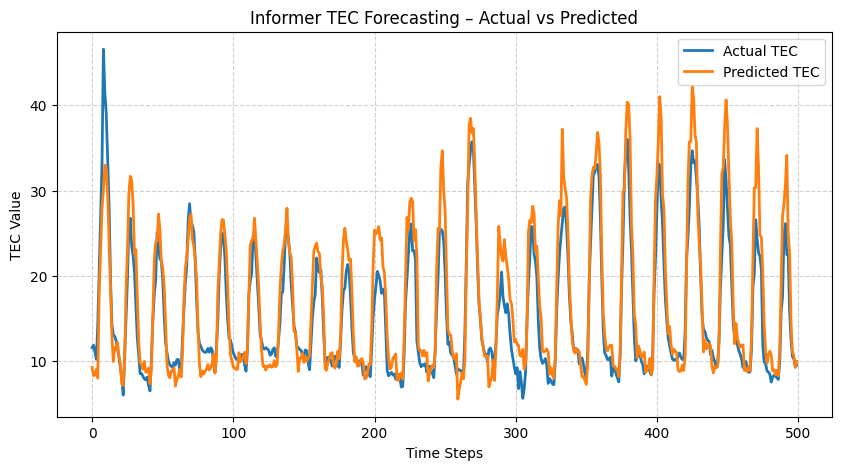

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()
preds, trues = [], []

with torch.no_grad():
    for seq_x, seq_y in test_loader:
        seq_x, seq_y = seq_x.to(device), seq_y.to(device)
        output = model(seq_x)

        preds.append(output.cpu().numpy())

        # Handle 2D or 3D target tensors
        if seq_y.ndim == 3:
            trues.append(seq_y[:, -1, :output.shape[-1]].cpu().numpy())
        else:
            trues.append(seq_y.cpu().numpy())

# Convert to numpy arrays
preds = np.concatenate(preds).flatten()
trues = np.concatenate(trues).flatten()

# Inverse transform to original TEC values
preds_real = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
trues_real = scaler_y.inverse_transform(trues.reshape(-1, 1)).flatten()

# Compute metrics
mae = np.mean(np.abs(preds_real - trues_real))
rmse = np.sqrt(np.mean((preds_real - trues_real) ** 2))

print(f"📊 Model Evaluation Metrics:")
print(f"   → Mean Absolute Error (MAE): {mae:.4f}")
print(f"   → Root Mean Square Error (RMSE): {rmse:.4f}")

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(trues_real[:500], label="Actual TEC", linewidth=2)
plt.plot(preds_real[:500], label="Predicted TEC", linewidth=2)
plt.title("Informer TEC Forecasting – Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("TEC Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


⚠️ Detected 20 potential ionospheric anomalies (|Z| > 2.5)


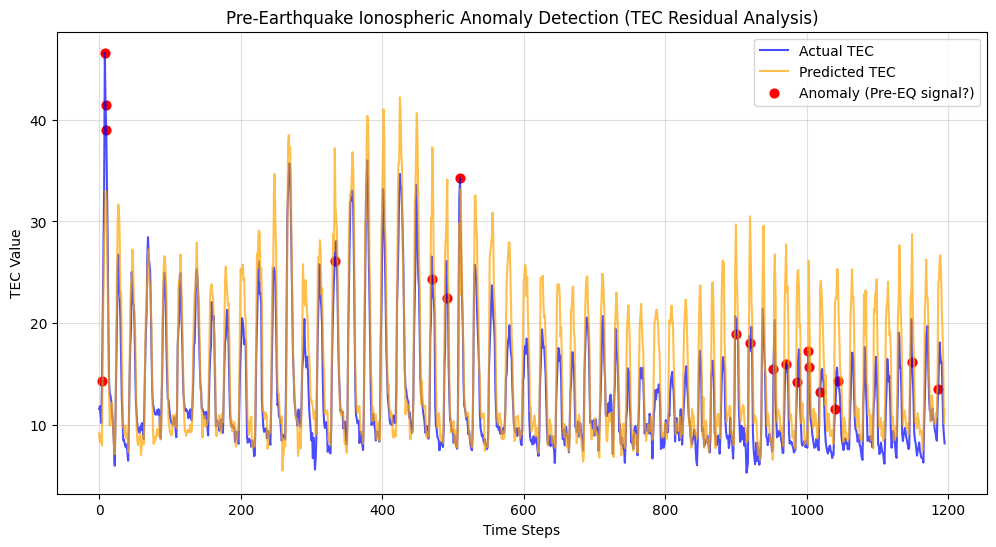

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Combine results into a DataFrame
results = pd.DataFrame({
    'Actual_TEC': trues_real,
    'Predicted_TEC': preds_real
})

# Compute residuals (difference between actual and predicted)
results['Residual'] = results['Actual_TEC'] - results['Predicted_TEC']

# Compute Z-scores to detect anomalies
results['Z_Score'] = zscore(results['Residual'])

# Flag anomalies (|Z| > 2.5 typically indicates unusual variation)
threshold = 2.5
results['Anomaly'] = np.where(np.abs(results['Z_Score']) > threshold, 1, 0)

# Print anomaly statistics
num_anomalies = results['Anomaly'].sum()
print(f"⚠️ Detected {num_anomalies} potential ionospheric anomalies (|Z| > {threshold})")

# Plot anomalies
plt.figure(figsize=(12,6))
plt.plot(results['Actual_TEC'], label='Actual TEC', color='blue', alpha=0.7)
plt.plot(results['Predicted_TEC'], label='Predicted TEC', color='orange', alpha=0.7)
plt.scatter(results.index[results['Anomaly']==1],
            results['Actual_TEC'][results['Anomaly']==1],
            color='red', label='Anomaly (Pre-EQ signal?)', s=40)
plt.legend()
plt.title("Pre-Earthquake Ionospheric Anomaly Detection (TEC Residual Analysis)")
plt.xlabel("Time Steps")
plt.ylabel("TEC Value")
plt.grid(alpha=0.4)
plt.show()


In [78]:
!git config --global user.name "ChanchalRawate"
!git config --global user.email "20je0283@iitism.ac.in"


In [81]:
!git clone https://github.com/ChanchalRawate/Informer-tec-earthquake-prediction

fatal: destination path 'Informer-tec-earthquake-prediction' already exists and is not an empty directory.


In [82]:
%cd Informer-tec-earthquake-prediction


/content/Informer-tec-earthquake-prediction/Informer-tec-earthquake-prediction


In [85]:
!mv /content/Informer_tec_model.ipynb /content/Informer-tec-earthquake-prediction/


mv: cannot stat '/content/Informer_tec_model.ipynb': No such file or directory


In [86]:
!pwd


/content/Informer-tec-earthquake-prediction/Informer-tec-earthquake-prediction


In [87]:
!ls /content


drive  Informer-tec-earthquake-prediction  sample_data


In [90]:
/content/drive/MyDrive/Colab Notebooks/<TEC_Project.ipynb>.ipynb


SyntaxError: invalid syntax (ipython-input-945128186.py, line 1)

In [91]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
!cp "/content/drive/MyDrive/Colab Notebooks/TEC_Project.ipynb" "/content/Informer-tec-earthquake-prediction/"


In [93]:
!ls /content/Informer-tec-earthquake-prediction


Informer-tec-earthquake-prediction  README.md  TEC_Project.ipynb


In [94]:
%cd /content/Informer-tec-earthquake-prediction
!git add .
!git commit -m "Added Informer TEC model Colab notebook"
!git push origin main


/content/Informer-tec-earthquake-prediction
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Informer-tec-earthquake-prediction
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Informer-tec-earthquake-prediction
hint: 
hint: See "git help submodule" for more information.
[main 7597a10] Added Informer TEC model Colab notebook
 2 files changed, 2 insertions(+)
 create mode 160000 Informer-tec-earthquake-prediction
 create mode 100644 TEC_Project.ipynb
fatal: could not read Username for 'https://github.com': No such device or address


In [95]:
%cd /content
!rm -rf Informer-tec-earthquake-prediction


/content


In [ ]:
!git clone https://github.com/ChanchalRawate/Informer-tec-earthquake-prediction.git
%cd Informer-tec-earthquake-prediction
